# Single-day EDA: train on one capture day, test on another

**Question.** If a model only ever sees one day of traffic, how well does it detect the attacks on
a different day? In CIC-IDS2017 each attack type appears on a single day, so a different day
means attack types the model has never seen.

**Setup.**
- Explore the training day: what's in it, and which features separate its attacks from benign traffic.
- Compare it to the test day.
- Train two baselines on the training day only, with the same settings as `cicids2017_eda.ipynb`:
  - Logistic regression (supervised; uses the attack labels).
  - Isolation Forest (unsupervised; trained on benign flows only).
- Test both on a held-out 20% of the training day (same day) and on the whole test day (other day).

Change `TRAIN_DAY` / `TEST_DAY` below to try another pairing. The training day must contain
attacks, so Monday (benign only) can't be the training day.

In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.models.evaluate import threshold_at_fpr

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

TRAIN_DAY = "Tuesday-WorkingHours"      # FTP-Patator, SSH-Patator
TEST_DAY = "Wednesday-workingHours"     # DoS family, Heartbleed
TARGET_FPR = 0.01                       # alert budget used to compare the two models
RANDOM_STATE = 42

df = pd.read_parquet("../data/processed/cicids2017_clean_v2.parquet")
assert {TRAIN_DAY, TEST_DAY} <= set(df["Meta_source"]), sorted(df["Meta_source"].unique())

train_day = df[df["Meta_source"] == TRAIN_DAY].reset_index(drop=True)
test_day = df[df["Meta_source"] == TEST_DAY].reset_index(drop=True)

feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
assert len(feature_cols) == 71, len(feature_cols)
print(f"{TRAIN_DAY}: {len(train_day):,} flows | {TEST_DAY}: {len(test_day):,} flows | {len(feature_cols)} features")

Tuesday-WorkingHours: 409,928 flows | Wednesday-workingHours: 590,299 flows | 71 features


## 1. EDA of the training day

In [2]:
def label_table(day_df):
    counts = day_df["Label"].value_counts()
    return pd.DataFrame({"flows": counts, "share": (counts / counts.sum()).round(4)})

print(f"Attack share: {(train_day['Label'] != 'BENIGN').mean():.3f}")
label_table(train_day)

Attack share: 0.022


,flows,share
Label,,
BENIGN,400778,0.9777
FTP-Patator,5931,0.0145
SSH-Patator,3219,0.0079


Which features separate this day's attacks from its benign traffic? As a quick first screen,
we use each feature on its own as a score and compute its ROC-AUC against the attack label:
the probability that a random attack flow has a higher value than a random benign flow.

- AUC 0.5: the feature carries no ranking information.
- AUC near 1: attacks have higher values.
- AUC near 0: attacks have lower values. This is just as useful; flip the sign and it becomes 1 - AUC.

So we rank by `|AUC - 0.5|`, which measures strength regardless of direction. This screen only
looks at one feature at a time, so it misses interactions, repeats redundant features, and treats
`Destination Port` as a number when it is really a category.

In [3]:
y_train_day = (train_day["Label"] != "BENIGN").astype(int).values
single_feature_auc = pd.Series({c: roc_auc_score(y_train_day, train_day[c]) for c in feature_cols})

feature_ranking = pd.DataFrame({
    "roc_auc": single_feature_auc,
    "|AUC - 0.5|": (single_feature_auc - 0.5).abs(),
    "attacks have": np.where(single_feature_auc > 0.5, "higher values", "lower values"),
}).sort_values("|AUC - 0.5|", ascending=False)

top_features = feature_ranking.index[:6].tolist()
feature_ranking.head(10).round(3)

,roc_auc,|AUC - 0.5|,attacks have
Destination Port,0.003,0.497,lower values
Init_Win_bytes_forward,0.810,0.310,higher values
Fwd Header Length,0.810,0.310,higher values
Fwd IAT Total,0.781,0.281,higher values
Has_Init_Win_bwd,0.778,0.278,higher values
Subflow Bwd Packets,0.773,0.273,higher values
Total Backward Packets,0.773,0.273,higher values
Bwd Header Length,0.767,0.267,higher values
Total Fwd Packets,0.767,0.267,higher values
Subflow Fwd Packets,0.767,0.267,higher values


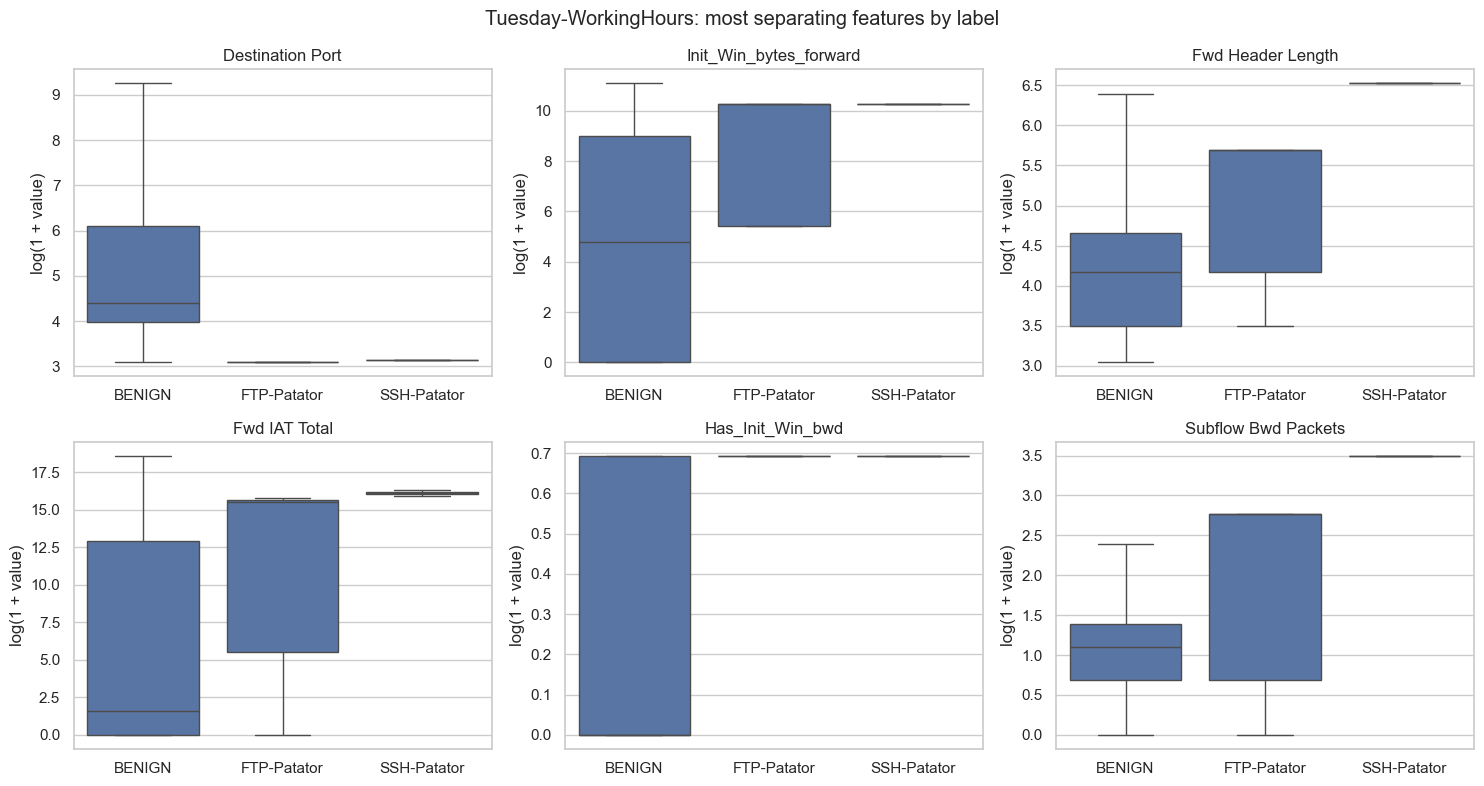

In [4]:
# Boxplots of the six most separating features (log scale; sample benign to keep it readable)
sample = pd.concat([
    train_day[train_day["Label"] == "BENIGN"].sample(20_000, random_state=RANDOM_STATE),
    train_day[train_day["Label"] != "BENIGN"],
])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, top_features):
    sns.boxplot(data=sample, x="Label", y=np.log1p(sample[col].clip(lower=0)), ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("log(1 + value)")
fig.suptitle(f"{TRAIN_DAY}: most separating features by label")
fig.tight_layout()
plt.show()

In [5]:
# Destination ports per label: brute-force tools target one service each
(train_day.groupby("Label")["Destination Port"]
    .agg(lambda s: s.value_counts(normalize=True).head(3).round(3).to_dict())
    .to_frame("top destination ports (share of flows)"))

,top destination ports (share of flows)
Label,
BENIGN,"{53: 0.431, 443: 0.228, 80: 0.105}"
FTP-Patator,"{21: 1.0, 80: 0.0}"
SSH-Patator,{22: 1.0}


## 2. How different is the test day?

In [6]:
print(f"Attack share: {(test_day['Label'] != 'BENIGN').mean():.3f}")
label_table(test_day)

Attack share: 0.328


,flows,share
Label,,
BENIGN,396673,0.6720
DoS Hulk,172717,0.2926
DoS GoldenEye,10286,0.0174
DoS slowloris,5384,0.0091
DoS Slowhttptest,5228,0.0089
Heartbleed,11,0.0000


In [7]:
# Median of the training day's most separating features, per label, on both days.
# If the test day's attacks look like the training day's benign traffic on these features,
# a model that relies on them will miss the test day's attacks.
both = pd.concat([train_day.assign(day="train"), test_day.assign(day="test")])
both.groupby(["day", "Label"])[top_features].median().round(1)

Destination Port  Init_Win_bytes_forward  \
day   Label                                                        
test  BENIGN                        80.0                   118.0   
      DoS GoldenEye                 80.0                 29200.0   
      DoS Hulk                      80.0                   251.0   
      DoS Slowhttptest              80.0                 29200.0   
      DoS slowloris                 80.0                 29200.0   
      Heartbleed                   444.0                   235.0   
train BENIGN                        80.0                   118.0   
      FTP-Patator                   21.0                 29200.0   
      SSH-Patator                   22.0                 29200.0   

                        Fwd Header Length  Fwd IAT Total  Has_Init_Win_bwd  \
day   Label                                                                  
test  BENIGN                         64.0           18.0               0.0   
      DoS GoldenEye                 232.0      6674567.5               1.0   
      DoS Hulk                      200.0     86400000.0               1.0   
      DoS Slowhttptest              280.0     63100000.0               0.0   
      DoS slowloris                 120.0    100000000.0               1.0   
      Heartbleed                  89356.0    119000000.0               1.0   
train BENIGN                         64.0            4.0               0.0   
      FTP-Patator                   296.0      5721148.0               1.0   
      SSH-Patator                   680.0     10100000.0               1.0   

                        Subflow Bwd Packets  
day   Label                                  
test  BENIGN                            2.0  
      DoS GoldenEye                     5.0  
      DoS Hulk                          6.0  
      DoS Slowhttptest                  0.0  
      DoS slowloris                     2.0  
      Heartbleed                     2069.0  
train BENIGN                            2.0  
      FTP-Patator                      15.0  
      SSH-Patator                      32.0

## 3. Train on one day, test on another

- The training day is split 80/20 (stratified). Both models train on the 80% only.
- **Logistic regression:** `StandardScaler -> LogisticRegression(class_weight="balanced")`, as in
  `cicids2017_eda.ipynb`.
- **Isolation Forest:** 200 trees, trained on the benign flows of the 80% only, scaled with a
  scaler fit on those benign flows. Higher anomaly score = more likely attack.
- Both test sets keep their natural prevalence.

The two models' default thresholds aren't comparable (0.5 probability vs. Isolation Forest's
`contamination="auto"`), so we also report recall at a fixed 1% false positive rate on each test
set's benign traffic. That is the same alert budget for both models.

In [8]:
X_day = train_day[feature_cols].values
X_tr, X_same, y_tr, y_same, labels_tr, labels_same = train_test_split(
    X_day, y_train_day, train_day["Label"].values,
    test_size=0.2, stratify=y_train_day, random_state=RANDOM_STATE,
)
X_other = test_day[feature_cols].values
y_other = (test_day["Label"] != "BENIGN").astype(int).values
labels_other = test_day["Label"].values

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, n_jobs=-1, class_weight="balanced"),
).fit(X_tr, y_tr)

X_tr_benign = X_tr[y_tr == 0]
iso_scaler = StandardScaler().fit(X_tr_benign)
iso_forest = IsolationForest(
    n_estimators=200, max_samples="auto", contamination="auto", random_state=RANDOM_STATE, n_jobs=-1,
).fit(iso_scaler.transform(X_tr_benign))

def scores_and_preds(model_name, X):
    """Attack score (higher = more likely attack) and default-threshold prediction."""
    if model_name == "Logistic regression":
        proba = log_reg.predict_proba(X)[:, 1]
        return proba, (proba >= 0.5).astype(int)
    X_iso = iso_scaler.transform(X)
    return -iso_forest.decision_function(X_iso), (iso_forest.predict(X_iso) == -1).astype(int)

print(f"Trained on {len(X_tr):,} flows ({y_tr.sum():,} attacks); Isolation Forest on {len(X_tr_benign):,} benign flows")

Trained on 327,942 flows (7,320 attacks); Isolation Forest on 320,622 benign flows


In [9]:
test_sets = {
    f"Same day ({TRAIN_DAY}, 20%)": (X_same, y_same, labels_same),
    f"Other day ({TEST_DAY})": (X_other, y_other, labels_other),
}
models = ["Logistic regression", "Isolation Forest"]

rows, results = [], {}
for test_name, (X, y, labels) in test_sets.items():
    for model_name in models:
        scores, preds = scores_and_preds(model_name, X)
        precision, recall, _, _ = precision_recall_fscore_support(y, preds, average="binary", zero_division=0)
        threshold, actual_fpr, recall_at_fpr = threshold_at_fpr(y, scores, TARGET_FPR)
        results[test_name, model_name] = (scores, threshold)
        rows.append({
            "test set": test_name, "model": model_name,
            "PR-AUC": average_precision_score(y, scores), "no-skill PR-AUC": y.mean(),
            "precision (default)": precision, "recall (default)": recall,
            f"recall at {TARGET_FPR:.0%} FPR": recall_at_fpr,
        })

summary = pd.DataFrame(rows).set_index(["test set", "model"]).round(3)
summary

PR-AUC  \
test set                             model                         
Same day (Tuesday-WorkingHours, 20%) Logistic regression   0.984   
                                     Isolation Forest      0.040   
Other day (Wednesday-workingHours)   Logistic regression   0.214   
                                     Isolation Forest      0.838   

                                                          no-skill PR-AUC  \
test set                             model                                  
Same day (Tuesday-WorkingHours, 20%) Logistic regression            0.022   
                                     Isolation Forest               0.022   
Other day (Wednesday-workingHours)   Logistic regression            0.328   
                                     Isolation Forest               0.328   

                                                          precision (default)  \
test set                             model                                      
Same day (Tuesday-WorkingHours, 20%) Logistic regression                0.691   
                                     Isolation Forest                   0.000   
Other day (Wednesday-workingHours)   Logistic regression                0.156   
                                     Isolation Forest                   0.828   

                                                          recall (default)  \
test set                             model                                   
Same day (Tuesday-WorkingHours, 20%) Logistic regression             0.996   
                                     Isolation Forest                0.000   
Other day (Wednesday-workingHours)   Logistic regression             0.004   
                                     Isolation Forest                0.876   

                                                          recall at 1% FPR  
test set                             model                                  
Same day (Tuesday-WorkingHours, 20%) Logistic regression             0.996  
                                     Isolation Forest                0.000  
Other day (Wednesday-workingHours)   Logistic regression             0.004  
                                     Isolation Forest                0.130

In [10]:
# At the default threshold, how often does each model flag benign traffic on each test set?
# This checks that a high attack recall isn't just the model flagging everything.
pd.DataFrame({
    test_name: {m: scores_and_preds(m, X[y == 0])[1].mean() for m in models}
    for test_name, (X, y, _) in test_sets.items()
}).round(3).rename_axis("benign flows flagged (default threshold)")

,"Same day (Tuesday-WorkingHours, 20%)",Other day (Wednesday-workingHours)
benign flows flagged (default threshold),,
Logistic regression,0.010,0.011
Isolation Forest,0.081,0.089


Logistic regression's single strongest feature on the training day is `Destination Port`
(single-feature ROC-AUC far from 0.5 above): every FTP-Patator flow goes to port 21 and every
SSH-Patator flow to port 22. The test day's attacks are all web traffic. To check how much the
model leans on the port, we retrain it without that one column.

In [11]:
no_port = [i for i, c in enumerate(feature_cols) if c != "Destination Port"]
log_reg_no_port = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, n_jobs=-1, class_weight="balanced"),
).fit(X_tr[:, no_port], y_tr)

pd.DataFrame({
    test_name: {
        "with Destination Port": summary.loc[(test_name, "Logistic regression"), "PR-AUC"],
        "without Destination Port": average_precision_score(y, log_reg_no_port.predict_proba(X[:, no_port])[:, 1]),
        "no-skill": y.mean(),
    }
    for test_name, (X, y, _) in test_sets.items()
}).T.round(3).rename_axis("logistic regression PR-AUC")

,with Destination Port,without Destination Port,no-skill
logistic regression PR-AUC,,,
"Same day (Tuesday-WorkingHours, 20%)",0.984,0.973,0.022
Other day (Wednesday-workingHours),0.214,0.201,0.328


In [12]:
# Per-attack recall at the 1% FPR threshold
per_attack = {}
for (test_name, model_name), (scores, threshold) in results.items():
    labels = test_sets[test_name][2]
    flagged = scores >= threshold
    per_attack[test_name, model_name] = {
        label: flagged[labels == label].mean() for label in np.unique(labels) if label != "BENIGN"
    }
per_attack_df = pd.DataFrame(per_attack).round(3)
per_attack_df.insert(0, "n (test)", [
    int((test_sets[next(k for k in test_sets if label in set(test_sets[k][2]))][2] == label).sum())
    for label in per_attack_df.index
])
per_attack_df

n (test) Same day (Tuesday-WorkingHours, 20%)  \
                                           Logistic regression   
FTP-Patator          1165                                0.996   
SSH-Patator           665                                0.995   
DoS GoldenEye       10286                                  NaN   
DoS Hulk           172717                                  NaN   
DoS Slowhttptest     5228                                  NaN   
DoS slowloris        5384                                  NaN   
Heartbleed             11                                  NaN   

                                  Other day (Wednesday-workingHours)  \
                 Isolation Forest                Logistic regression   
FTP-Patator                   0.0                                NaN   
SSH-Patator                   0.0                                NaN   
DoS GoldenEye                 NaN                              0.000   
DoS Hulk                      NaN                              0.004   
DoS Slowhttptest              NaN                              0.001   
DoS slowloris                 NaN                              0.022   
Heartbleed                    NaN                              0.000   

                                   
                 Isolation Forest  
FTP-Patator                   NaN  
SSH-Patator                   NaN  
DoS GoldenEye               0.000  
DoS Hulk                    0.145  
DoS Slowhttptest            0.000  
DoS slowloris               0.000  
Heartbleed                  1.000

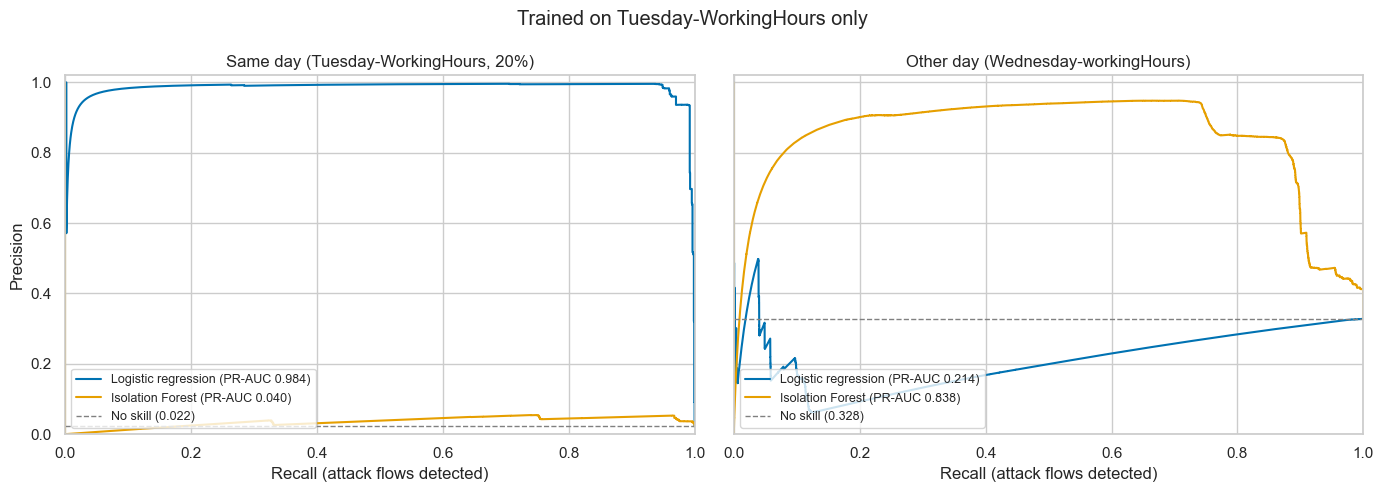

In [13]:
# Okabe-Ito colorblind-safe palette
colors = {"Logistic regression": "#0072B2", "Isolation Forest": "#E69F00"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (test_name, (X, y, _)) in zip(axes, test_sets.items()):
    for model_name in models:
        scores, _ = results[test_name, model_name]
        precision, recall, _ = precision_recall_curve(y, scores)
        ax.plot(recall, precision, color=colors[model_name],
                label=f"{model_name} (PR-AUC {average_precision_score(y, scores):.3f})")
    ax.axhline(y.mean(), color="gray", linestyle="--", linewidth=1, label=f"No skill ({y.mean():.3f})")
    ax.set_title(test_name)
    ax.set_xlabel("Recall (attack flows detected)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left", fontsize=9)
axes[0].set_ylabel("Precision")
fig.suptitle(f"Trained on {TRAIN_DAY} only")
fig.tight_layout()
plt.show()

## 4. Summary

Trained on Tuesday (FTP-Patator, SSH-Patator) only. All numbers are from the cells above.

**Same day (Tuesday, held-out 20%).** Logistic regression is near perfect: PR-AUC 0.984 against
a no-skill of 0.022, and recall 0.996 at 1% FPR. Isolation Forest is barely above no-skill
(PR-AUC 0.040) and catches no brute-force flows at either threshold, even though it flags 8.1% of
benign flows. To an anomaly detector, repeated login attempts look like ordinary traffic.

**Other day (Wednesday, DoS family + Heartbleed).** The result flips. Logistic regression drops
to PR-AUC 0.214, below the no-skill 0.328, so it ranks Wednesday's attacks worse than chance. It
catches 0.4% of attack flows at its default threshold. Dropping `Destination Port` doesn't
change this (0.201), so the failure is not the port shortcut. Isolation Forest reaches PR-AUC
0.838 and catches 87.6% of attack flows at its default threshold. It flags 8.9% of Wednesday's
benign flows, close to its 8.1% on Tuesday, so it is not just flagging everything on a new day.

**Is Isolation Forest's Wednesday result good?** It ranks Wednesday's attacks well (PR-AUC
0.838 against a no-skill of 0.328), and it is by far the better of the two models on that day.
The problem is the threshold. Its default threshold flags 8.9% of benign flows: about 35,000
false alerts on Wednesday alone (0.089 × 396,673 benign flows). Limited to 1% of benign flows,
its recall falls to 0.130, almost all of it DoS Hulk (0.145). GoldenEye, slowloris and
Slowhttptest are 0.000. It catches all 11 Heartbleed flows, but 11 flows is too few to mean much.

**What this shows.** Each model works on one day and not the other. The supervised model learns
the attacks it was shown and does not transfer to a different attack family. Isolation Forest does
not depend on which attacks it saw. It catches attacks that make flows unusual (DoS Hulk's long
flows) and misses attacks that look like normal sessions (brute-force logins). The random-split
comparison in `cicids2017_eda.ipynb` (logistic regression 0.955 vs. Isolation Forest 0.540)
favoured logistic regression because that split only tests attack types seen in training.

**Limits.** One day pair and one seed. Isolation Forest's default threshold flags about 9% of
benign flows, far too many alerts for real traffic volumes. At a 1% budget it still beats logistic
regression (recall 0.130 vs. 0.004), but it catches few attacks. The reverse pairing (train Wednesday, test Tuesday) and other days are one change to
`TRAIN_DAY`/`TEST_DAY` away.